## Working for MNIST dataset

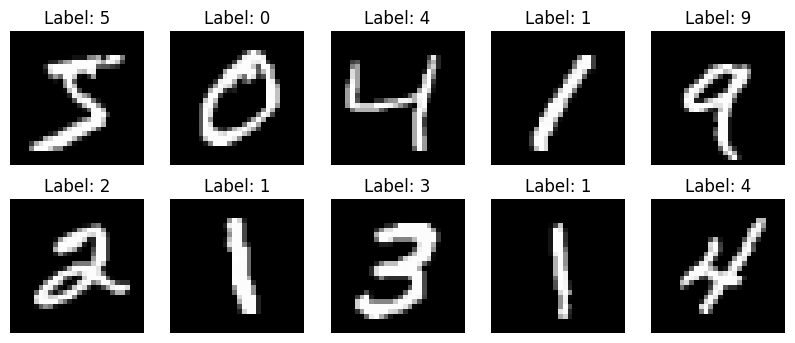

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9189 - loss: 0.2788 - val_accuracy: 0.9836 - val_loss: 0.0460
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9871 - loss: 0.0415 - val_accuracy: 0.9874 - val_loss: 0.0376
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9914 - loss: 0.0278 - val_accuracy: 0.9906 - val_loss: 0.0277
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9939 - loss: 0.0189 - val_accuracy: 0.9910 - val_loss: 0.0295
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9960 - loss: 0.0126 - val_accuracy: 0.9862 - val_loss: 0.0461


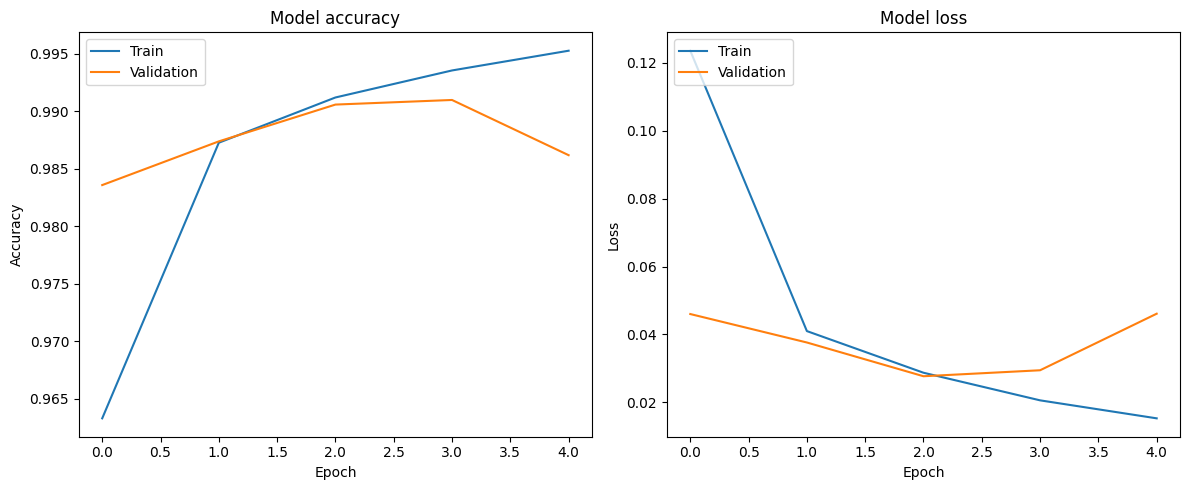

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9815 - loss: 0.0612
Test accuracy: 0.9862
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)                   │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

Predicted labels: [7 2 1 0 4]


In [42]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)

# Define a simple CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])

# Compile the model
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Train the model and capture history
history = model.fit(x_train, y_train,
                    epochs=5,
                    batch_size=32,
                    validation_data=(x_test, y_test))

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)

# Model summary
model.summary()
print("Predicted labels:", predicted_labels)

#Implement an End to End CNN Model for Image Classification Task.

In [43]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from PIL import Image

#Task 01: Data Understanding and Visualization



In [44]:
train_folder = "/content/drive/MyDrive/AL ML/FruitinAmazon/train"
test_folder = "/content/drive/MyDrive/AL ML/FruitinAmazon/test"

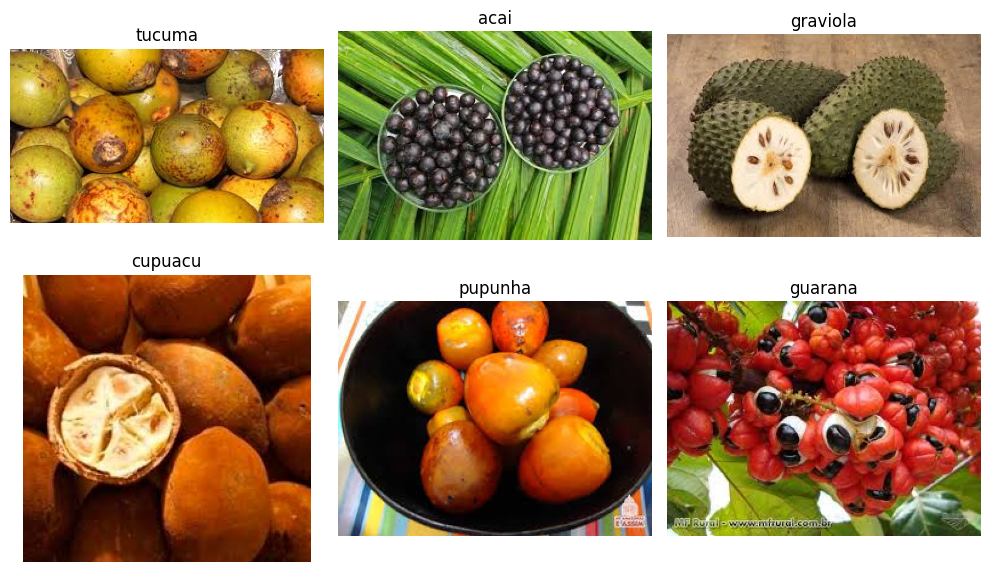

In [45]:
# Get the list of class directories
class_names = [d for d in os.listdir(train_folder) if os.path.isdir(os.path.join(train_folder, d))]

# Select one random image from each class
selected_images = []
for class_name in class_names:
    class_path = os.path.join(train_folder, class_name)
    images = os.listdir(class_path)

    # Randomly select one image
    if images:
        selected_image = random.choice(images)
        selected_images.append((class_name, os.path.join(class_path, selected_image)))

# Display images in a grid with two rows
num_classes = len(selected_images)
cols = (num_classes + 1) // 2  # Number of columns in the grid

fig, axes = plt.subplots(2, cols, figsize=(10, 6))
axes = axes.flatten()  # Flatten for easy indexing

for i, (class_name, image_path) in enumerate(selected_images):
    img = mpimg.imread(image_path)  # Load image
    axes[i].imshow(img)  # Show image
    axes[i].set_title(class_name)  # Set title
    axes[i].axis("off")  # Hide axes

# Hide unused axes if any
for i in range(len(selected_images), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

**What did you observe?**

Since the selection is random, running the script multiple times gives different images each time.

The script randomly picks one class folder from the dataset.Then, it randomly selects one image from that class.The image file name and path are printed.

2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”

In [46]:


# Define the path to the train folder
train_folder = "/content/drive/MyDrive/AL ML/FruitinAmazon/train"

# List to keep track of corrupted images
corrupted_images = []

# Iterate through each class subdirectory
for class_name in os.listdir(train_folder):
    class_path = os.path.join(train_folder, class_name)

    if os.path.isdir(class_path):  # Ensure it's a directory
        # Iterate through each image file in the class folder
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            try:
                # Try opening the image
                with Image.open(image_path) as img:
                    img.verify()  # Verify if the image is valid
            except (IOError, SyntaxError):
                # If an error occurs, it means the image is corrupted
                corrupted_images.append(image_path)
                os.remove(image_path)  # Remove the corrupted image
                print(f"Removed corrupted image: {image_path}")

# Check if any corrupted images were found
if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")


No corrupted images found.


# Task 2: Loading and Preprocessing Image Data in keras


In [47]:
# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
     train_folder, labels='inferred',
     label_mode='int',
     image_size=(img_height, img_width),
     interpolation='nearest',
     batch_size= batch_size,
     shuffle=True,
     validation_split=validation_split,
     subset='training',
     seed=123
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [48]:

# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_folder,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_folder,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


#Finding image shape

In [49]:
for image_batch, labels_batch in train_ds.take(1):  # Get one batch
    print(image_batch.shape)  # Prints (batch_size, height, width, channels)
    break

(32, 128, 128, 3)


# Task-03 : Implement CNN model


In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

num_classes = len(class_names)

model = Sequential([
    # Convolutional Layer 1
    Conv2D(32, (3, 3), padding='same', strides=1, activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D((2, 2), strides=2),

    # Convolutional Layer 2
    Conv2D(32, (3, 3), padding='same', strides=1, activation='relu'),
    MaxPooling2D((2, 2), strides=2),

    # Fully Connected Network
    Flatten(),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 04: Compile and Train the model

In [51]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
checkpoint_cb = callbacks.ModelCheckpoint("best_model.h5", save_best_only=True)
early_stopping_cb = callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Train the model
model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=8,
    epochs=1000,
    callbacks=[checkpoint_cb, early_stopping_cb],
)

model.summary()

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.1256 - loss: 1.8657

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 687ms/step - accuracy: 0.1220 - loss: 1.8826 - val_accuracy: 0.0000e+00 - val_loss: 3.4874
Epoch 2/1000
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.2969 - loss: 2.1954

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.2804 - loss: 2.1422 - val_accuracy: 0.0556 - val_loss: 1.7061
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.4115 - loss: 1.6037 - val_accuracy: 0.0556 - val_loss: 1.8487
Epoch 4/1000
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4062 - loss: 1.5681 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.4115 - loss: 1.5529 - val_accuracy: 0.2778 - val_loss: 1.5227
Epoch 5/1000
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.4141 - loss: 1.3839

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.4570 - loss: 1.3346 - val_accuracy: 0.6111 - val_loss: 1.1320
Epoch 6/1000
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7578 - loss: 0.9696 

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,349,364 (24.22 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,232,910 (16.15 MB)

# Task 05: Evaluate the model


In [52]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_folder, labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size= batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
  )

Found 30 files belonging to 6 classes.
Using 24 files for training.


In [53]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.6250 - loss: 122.9767
Test Loss: 122.9767
Test Accuracy: 0.6250


# Task 06: Save and load the model

In [54]:
# Save the model
model.save('trained_model.h5')

# Load the model
loaded_model = keras.models.load_model('trained_model.h5')

# Re-evaluate the model on the test set
test_loss, test_accuracy = loaded_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step - accuracy: 0.6250 - loss: 122.9767
Test Loss: 122.9767
Test Accuracy: 0.6250


# Task 07: Predictions and Classification reports

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
              precision    recall  f1-score   support

      tucuma       0.75      0.75      0.75         4
        acai       0.50      0.50      0.50         4
    graviola       0.57      1.00      0.73         4
     cupuacu       0.75      1.00      0.86         3
     pupunha       1.00      0.40      0.57         5
     guarana       0.33      0.25      0.29         4

    accuracy                           0.62        24
   macro avg       0.65      0.65      0.62        24
weighted avg       0.66      0.62      0.60        24



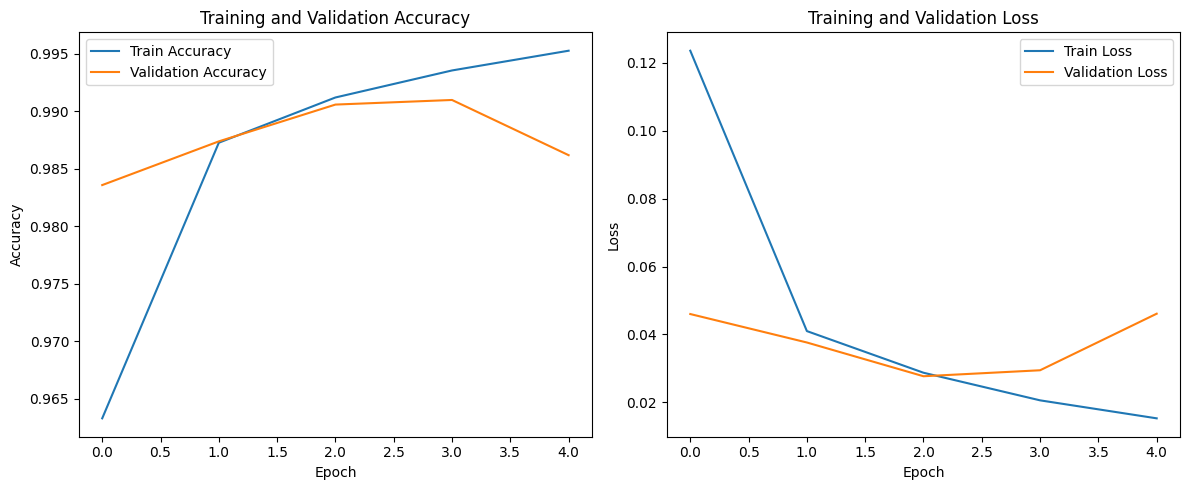

In [55]:
import numpy as np
from sklearn.metrics import classification_report

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    predictions = loaded_model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot training history
def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)